# Regression Modeling Project in Machine Learning 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df=pd.read_csv("delaney_solubility_with_descriptors.csv")
df.head()

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
0,2.5954,167.850,0.0,0.0,-2.18
1,2.3765,133.405,0.0,0.0,-2.00
2,2.5938,167.850,1.0,0.0,-1.74
3,2.0289,133.405,1.0,0.0,-1.48
4,2.9189,187.375,1.0,0.0,-3.04


In [3]:
X=df.drop('logS',axis=1)
#print(X)
Y=df['logS']
#print(Y)

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test,Y_train, Y_test=train_test_split(X,Y,test_size=0.2,random_state=100)
#Model Building
from sklearn import linear_model
Lr=linear_model.LinearRegression()
Lr.fit(X_train,Y_train)
#Apply model for Predictions
Y_Lr_train_pred=Lr.predict(X_train)
Y_Lr_test_pred=Lr.predict(X_test)

In [6]:
# Model Performance Evaluation
from sklearn.metrics import mean_squared_error, r2_score

Lr_train_mse=mean_squared_error(Y_train,Y_Lr_train_pred)
Lr_train_r2=r2_score(Y_train,Y_Lr_train_pred)

Lr_test_mse=mean_squared_error(Y_test,Y_Lr_test_pred)
Lr_test_r2=r2_score(Y_test,Y_Lr_test_pred)
print('Lr_mse(train):',Lr_train_mse,'Lr_r2(train):',Lr_train_r2,'Lr_mse(Test):',Lr_test_mse,'Lr_r2(Test):',Lr_test_r2)

Lr_mse(train): 1.0075362951093687 Lr_r2(train): 0.7645051774663391 Lr_mse(Test): 1.0206953660861033 Lr_r2(Test): 0.7891616188563282


# RANDOM FOREST FOR REGRESSION

In [7]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(max_depth=2,random_state=100)
rf.fit(X_train,Y_train)

Y_rf_train_pred=rf.predict(X_train)
Y_rf_test_pred=rf.predict(X_test)

In [8]:
#Model Performance Evaluation
from sklearn.metrics import mean_squared_error, r2_score

rf_train_mse=mean_squared_error(Y_train,Y_rf_train_pred)
rf_train_r2=r2_score(Y_train,Y_rf_train_pred)

rf_test_mse=mean_squared_error(Y_test,Y_rf_test_pred)
rf_test_r2=r2_score(Y_test,Y_rf_test_pred)
print('rf_mse(train):',rf_train_mse)
print('rf_r2(train):',rf_train_r2)
print('rf_mse(Test):',rf_test_mse)
print('rf_r2(Test):',rf_test_r2)


rf_mse(train): 1.028227802112806
rf_r2(train): 0.7596688824431413
rf_mse(Test): 1.407688264904896
rf_r2(Test): 0.7092230211002489


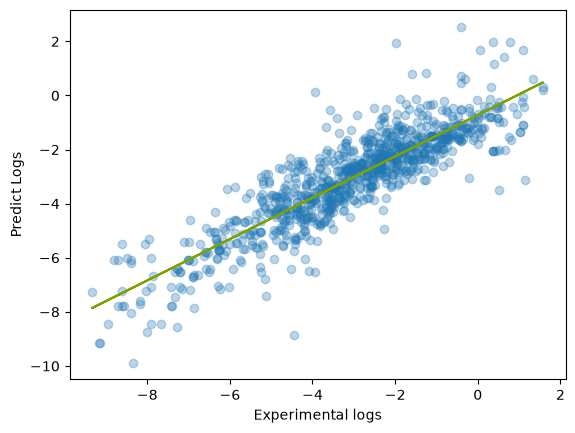

In [9]:


#DATA VISUALIZATIONOF RESULTS
plt.scatter(x=Y_train,y=Y_Lr_train_pred, alpha=0.3)
z=np.polyfit(Y_train,Y_Lr_train_pred,1)
p=np.poly1d(z)
plt.plot(Y_train,p(Y_train),'#7CA100')
plt.xlabel("Experimental logs")
plt.ylabel("Predict Logs")
plt.show()

